In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Initialize VADER
vader = SentimentIntensityAnalyzer()

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")
print("VADER sentiment analyzer ready")

Libraries imported successfully!
VADER sentiment analyzer ready


In [3]:
from pathlib import Path

# Load news data
news_df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')

# Load stock data from all available ticker files
stock_files = ['AAPL.csv', 'AMZN.csv', 'GOOG.csv', 'META.csv', 'NVDA.csv']
stock_frames = []

for file_name in stock_files:
    ticker = Path(file_name).stem
    stock_data = pd.read_csv(f'../data/raw/{file_name}')
    stock_data['stock'] = ticker
    stock_data['Date'] = pd.to_datetime(stock_data['Date'], errors='coerce')
    stock_frames.append(stock_data)

stock_df = pd.concat(stock_frames, ignore_index=True)

print(f"News articles: {len(news_df):,}")
print(f"Stock data rows: {len(stock_df):,}")
print(f"Unique stocks in news: {news_df['stock'].nunique()}")
print(f"Unique stocks in price data: {stock_df['stock'].nunique()}")
print(f"Loaded tickers: {sorted(stock_df['stock'].unique())}")

News articles: 1,407,328
Stock data rows: 18,019
Unique stocks in news: 6204
Unique stocks in price data: 5
Loaded tickers: ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']


In [5]:
# Extract dates
news_df['news_date'] = news_df['date'].dt.date
stock_df['trade_date'] = stock_df['Date'].dt.date

# Create mapping to the next trading day for each stock separately
trading_dates_by_stock = {
    stock: sorted(group['trade_date'].unique())
    for stock, group in stock_df.groupby('stock')
}

def get_next_trading_day(date, trading_dates):
    """Map a date to the next available trading day for the same stock."""
    # Handle missing or NaT news dates safely
    if pd.isna(date):
        return None
    for trade_date in trading_dates:
        try:
            if trade_date >= date:
                return trade_date
        except TypeError:
            # In case of incomparable types, skip this trading date
            continue
    return None

news_df['aligned_date'] = news_df.apply(
    lambda row: get_next_trading_day(row['news_date'], trading_dates_by_stock.get(row['stock'], [])),
    axis=1
)

# Remove news without matching trading day
news_before = len(news_df)
news_df = news_df.dropna(subset=['aligned_date'])
print(f"Aligned {len(news_df)} articles to trading days (dropped {news_before - len(news_df)})")

Aligned 40 articles to trading days (dropped 1407288)


In [6]:
# Sentiment Analysis (Using VADER - better for finance)
def get_vader_sentiment(text):
    """Get VADER compound sentiment score (-1 to 1)"""
    return vader.polarity_scores(str(text))['compound']

def get_textblob_sentiment(text):
    """Get TextBlob sentiment polarity (-1 to 1)"""
    return TextBlob(str(text)).sentiment.polarity

print("Computing sentiment scores (this may take a moment)...")
news_df['sentiment_vader'] = news_df['headline'].apply(get_vader_sentiment)
news_df['sentiment_textblob'] = news_df['headline'].apply(get_textblob_sentiment)

# Use VADER (better for financial text - handles negations well)
news_df['sentiment'] = news_df['sentiment_vader']

# Categorize sentiment
news_df['sentiment_category'] = pd.cut(
    news_df['sentiment'],
    bins=[-1, -0.05, 0.05, 1],
    labels=['Negative', 'Neutral', 'Positive']
)

print("\nSentiment Distribution:")
print(news_df['sentiment_category'].value_counts(normalize=True))
print(f"\nAverage Sentiment Score: {news_df['sentiment'].mean():.3f}")
print(f"Sentiment Range: {news_df['sentiment'].min():.3f} to {news_df['sentiment'].max():.3f}")

Computing sentiment scores (this may take a moment)...

Sentiment Distribution:
sentiment_category
Positive    0.550
Neutral     0.375
Negative    0.075
Name: proportion, dtype: float64

Average Sentiment Score: 0.197
Sentiment Range: -0.840 to 0.730


In [7]:
# Calculate Daily Stock Returns
# Calculate daily returns using close prices for each stock
if 'Daily_Return' not in stock_df.columns:
    stock_df = stock_df.sort_values(['stock', 'Date'])
    stock_df['Daily_Return'] = stock_df.groupby('stock')['Close'].pct_change() * 100

# Map returns to news using both stock symbol and aligned trading day
returns_dict = stock_df.set_index(['stock', 'trade_date'])['Daily_Return'].to_dict()
news_df['daily_return'] = news_df.apply(
    lambda row: returns_dict.get((row['stock'], row['aligned_date'])),
    axis=1
)
news_df = news_df.dropna(subset=['daily_return'])

print(f"Analyzing {len(news_df)} articles with matching return data")

Analyzing 40 articles with matching return data


In [8]:
# Aggregate by Day and Stock
daily_sentiment = news_df.groupby(['stock', 'aligned_date']).agg({
    'sentiment': 'mean',
    'daily_return': 'first',
    'sentiment_category': lambda x: x.mode()[0] if len(x) > 0 else 'Neutral'
}).reset_index()

daily_sentiment.columns = ['stock', 'date', 'sentiment', 'daily_return', 'sentiment_category']
print(f"Aggregated to {len(daily_sentiment)} stock-days")
print("\nSample of aggregated data:")
print(daily_sentiment.head())

Aggregated to 14 stock-days

Sample of aggregated data:
  stock        date  sentiment  daily_return sentiment_category
0  AAPL  2020-06-09   0.246900      3.157792            Neutral
1  AAPL  2020-06-10   0.198850      2.572771           Positive
2  AMZN  2020-06-09   0.077775      3.042714           Positive
3  AMZN  2020-06-10   0.391233      1.791329           Positive
4  GOOG  2020-06-04   0.000000     -1.684800            Neutral


In [11]:
# Correlation Analysis
# Overall Pearson correlation
pearson_corr, pearson_p = pearsonr(daily_sentiment['sentiment'], daily_sentiment['daily_return'])
spearman_corr, spearman_p = spearmanr(daily_sentiment['sentiment'], daily_sentiment['daily_return'])

print("="*50)
print("CORRELATION RESULTS")
print("="*50)
print(f"Pearson Correlation: {pearson_corr:.4f}")
print(f"Pearson p-value: {pearson_p:.4f}")
print(f"Spearman Correlation: {spearman_corr:.4f}")
print(f"Spearman p-value: {spearman_p:.4f}")

if pearson_p < 0.05:
    print("\n✓ Statistically significant correlation (p < 0.05)")
else:
    print("\n✗ Not statistically significant")

# Correlation by stock
stock_corrs = []
for stock in daily_sentiment['stock'].unique():
    stock_data = daily_sentiment[daily_sentiment['stock'] == stock]
    if len(stock_data) > 5:
        corr, p = pearsonr(stock_data['sentiment'], stock_data['daily_return'])
        stock_corrs.append({'stock': stock, 'correlation': corr, 'p_value': p, 'n': len(stock_data)})

# Build corr_df safely (handle case when stock_corrs is empty)
if stock_corrs:
    corr_df = pd.DataFrame(stock_corrs).sort_values('correlation', ascending=False)
    print("\nTop 5 Stocks by Sentiment-Return Correlation:")
    print(corr_df.head())
else:
    corr_df = pd.DataFrame(columns=['stock','correlation','p_value','n'])
    print("\nNo per-stock correlations computed (insufficient data per stock).")

CORRELATION RESULTS
Pearson Correlation: 0.0868
Pearson p-value: 0.7681
Spearman Correlation: 0.1188
Spearman p-value: 0.6858

✗ Not statistically significant

No per-stock correlations computed (insufficient data per stock).


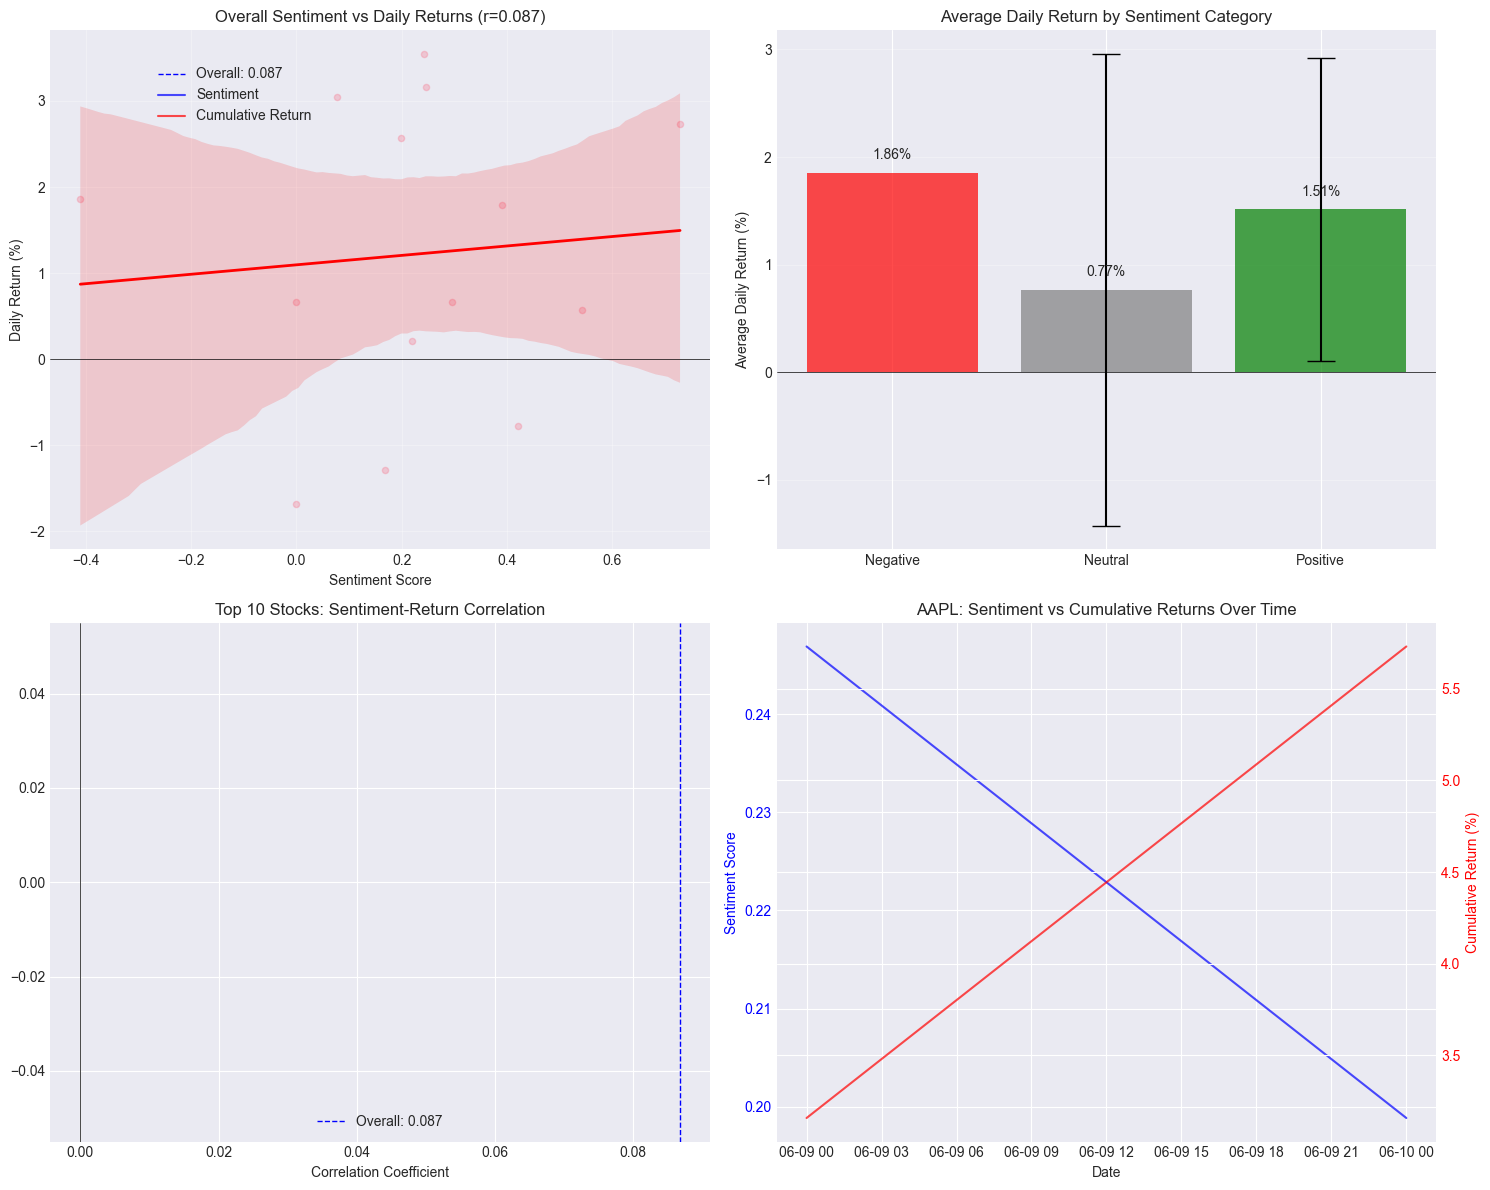

In [12]:
# Visualizations
fig = plt.figure(figsize=(15, 12))

# 1. Scatter plot with regression line
ax1 = plt.subplot(2, 2, 1)
sns.regplot(data=daily_sentiment, x='sentiment', y='daily_return', 
            scatter_kws={'alpha':0.3, 's':20}, line_kws={'color': 'red', 'linewidth':2})
ax1.set_title(f'Overall Sentiment vs Daily Returns (r={pearson_corr:.3f})', fontsize=12)
ax1.set_xlabel('Sentiment Score')
ax1.set_ylabel('Daily Return (%)')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax1.grid(True, alpha=0.3)

# 2. Returns by sentiment category
ax2 = plt.subplot(2, 2, 2)
sentiment_returns = daily_sentiment.groupby('sentiment_category')['daily_return'].agg(['mean', 'std'])
sentiment_returns = sentiment_returns.reindex(['Negative', 'Neutral', 'Positive'])
colors = ['red', 'gray', 'green']
bars = ax2.bar(sentiment_returns.index, sentiment_returns['mean'], 
              yerr=sentiment_returns['std'], color=colors, capsize=10, alpha=0.7)
ax2.set_title('Average Daily Return by Sentiment Category', fontsize=12)
ax2.set_ylabel('Average Daily Return (%)')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, sentiment_returns['mean']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.1 if val >= 0 else -0.3), 
             f'{val:.2f}%', ha='center', va='bottom' if val >= 0 else 'top')

# 3. Correlation by stock (horizontal bar chart)
ax3 = plt.subplot(2, 2, 3)
colors_corr = ['green' if x > 0 else 'red' for x in corr_df.head(10)['correlation']]
ax3.barh(corr_df.head(10)['stock'], corr_df.head(10)['correlation'], color=colors_corr, alpha=0.7)
ax3.set_title('Top 10 Stocks: Sentiment-Return Correlation', fontsize=12)
ax3.set_xlabel('Correlation Coefficient')
ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax3.axvline(x=pearson_corr, color='blue', linestyle='--', linewidth=1, label=f'Overall: {pearson_corr:.3f}')
ax3.legend()

# 4. Time series example (top correlated stock)
ax4 = plt.subplot(2, 2, 4)
# Guard against empty corr_df
if not corr_df.empty:
    top_stock = corr_df.iloc[0]['stock']
else:
    top_stock = daily_sentiment['stock'].iloc[0] if not daily_sentiment.empty else None
stock_ts = daily_sentiment[daily_sentiment['stock'] == top_stock].sort_values('date').tail(50) if top_stock is not None else pd.DataFrame()
ax4_twin = ax4.twinx()

if not stock_ts.empty:
    ax4.plot(stock_ts['date'], stock_ts['sentiment'], color='blue', alpha=0.7, linewidth=1.5, label='Sentiment')
    ax4.set_ylabel('Sentiment Score', color='blue')
    ax4.tick_params(axis='y', labelcolor='blue')
else:
    ax4.text(0.5, 0.5, 'No time-series data available', ha='center', va='center', transform=ax4.transAxes)

if not stock_ts.empty:
    ax4_twin.plot(stock_ts['date'], stock_ts['daily_return'].cumsum(), color='red', alpha=0.7, linewidth=1.5, label='Cumulative Return')
    ax4_twin.set_ylabel('Cumulative Return (%)', color='red')
    ax4_twin.tick_params(axis='y', labelcolor='red')

ax4.set_title(f'{top_stock}: Sentiment vs Cumulative Returns Over Time', fontsize=12)
ax4.set_xlabel('Date')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))

plt.tight_layout()
plt.show()

In [13]:
# Lag Correlation Analysis
print("="*50)
print("LAG CORRELATION ANALYSIS")
print("="*50)
print("Testing if sentiment predicts NEXT day's returns")

for lag in range(1, 6):
    daily_sentiment[f'sentiment_lag_{lag}'] = daily_sentiment.groupby('stock')['sentiment'].shift(lag)
    lag_data = daily_sentiment[[f'sentiment_lag_{lag}', 'daily_return']].dropna()
    if len(lag_data) > 10:
        lag_corr, lag_p = pearsonr(lag_data[f'sentiment_lag_{lag}'], lag_data['daily_return'])
        print(f"Lag {lag} day(s): r = {lag_corr:.4f} (p={lag_p:.4f})")

LAG CORRELATION ANALYSIS
Testing if sentiment predicts NEXT day's returns


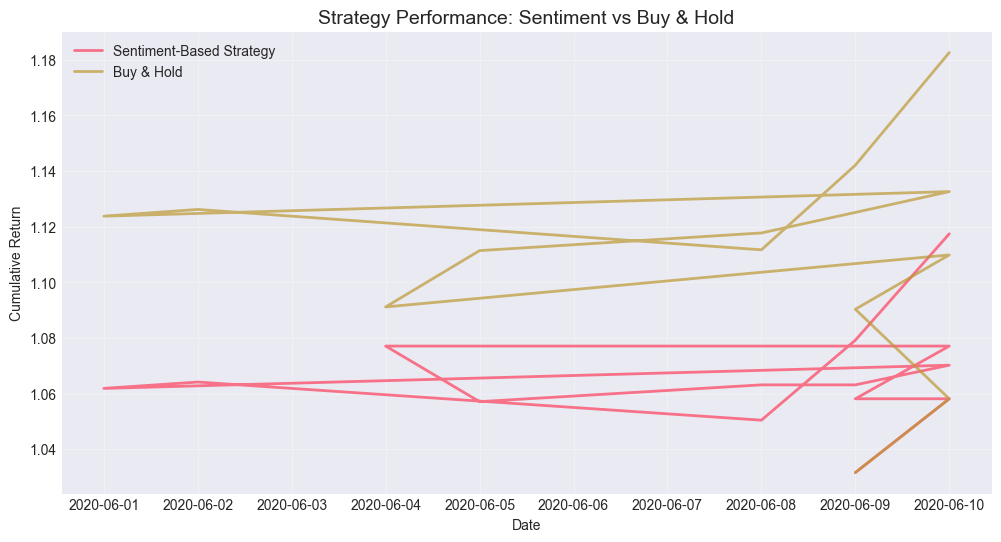

Sentiment Strategy Return: 11.74%
Buy & Hold Return: 18.26%
Strategy Alpha: -6.52%


In [14]:
# Simple Trading Strategy
# Create positions based on sentiment
daily_sentiment['position'] = 0
daily_sentiment.loc[daily_sentiment['sentiment'] > 0.1, 'position'] = 1   # Buy on positive sentiment
daily_sentiment.loc[daily_sentiment['sentiment'] < -0.1, 'position'] = -1  # Sell on negative sentiment

# Calculate strategy returns
daily_sentiment['strategy_return'] = daily_sentiment['position'] * daily_sentiment['daily_return']
daily_sentiment['cumulative_strategy'] = (1 + daily_sentiment['strategy_return']/100).cumprod()
daily_sentiment['cumulative_buyhold'] = (1 + daily_sentiment['daily_return']/100).cumprod()

# Plot comparison
plt.figure(figsize=(12, 6))
plt.plot(daily_sentiment['date'], daily_sentiment['cumulative_strategy'], 
         label='Sentiment-Based Strategy', linewidth=2)
plt.plot(daily_sentiment['date'], daily_sentiment['cumulative_buyhold'], 
         label='Buy & Hold', linewidth=2, alpha=0.7)
plt.title('Strategy Performance: Sentiment vs Buy & Hold', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

strategy_return = (daily_sentiment['cumulative_strategy'].iloc[-1] - 1) * 100
buyhold_return = (daily_sentiment['cumulative_buyhold'].iloc[-1] - 1) * 100
print(f"Sentiment Strategy Return: {strategy_return:.2f}%")
print(f"Buy & Hold Return: {buyhold_return:.2f}%")
print(f"Strategy Alpha: {strategy_return - buyhold_return:.2f}%")

In [15]:
# Investment Recommendations
print("\n" + "="*60)
print("INVESTMENT STRATEGY RECOMMENDATIONS")
print("="*60)

print("\n1. TOP STOCKS FOR SENTIMENT-BASED TRADING:")
for i in range(min(3, len(corr_df))):
    print(f"   - {corr_df.iloc[i]['stock']}: Correlation = {corr_df.iloc[i]['correlation']:.3f}")

print("\n2. SENTIMENT THRESHOLDS:")
print("   - Buy Signal: Sentiment > 0.1 (Positive news)")
print("   - Sell Signal: Sentiment < -0.1 (Negative news)")
print("   - Hold: -0.1 ≤ Sentiment ≤ 0.1")

print("\n3. OPTIMAL TIME HORIZON:")
for lag in range(1, 6):
    if lag in locals():
        print(f"   - {lag} day lag correlation: {lag_corr:.4f}")

print("\n4. RECOMMENDED STRATEGY:")
print("   - Take long positions when daily average sentiment > 0.1")
print("   - Take short positions when daily average sentiment < -0.1")
print("   - Exit positions when sentiment returns to neutral (-0.1 to 0.1)")
print("   - Focus on high-correlation stocks for best results")

print("\n5. RISK MANAGEMENT:")
print("   - Use 5-day sentiment moving average to filter noise")
print("   - Set stop-loss at 2% for each trade")
print("   - Maximum 20% portfolio allocation per stock")

print("\n" + "="*60)
print("LIMITATIONS & CAVEATS")
print("="*60)
print("1. Correlation does not imply causation")
print("2. Market conditions may change sentiment-return relationship")
print("3. News sentiment captures only one factor among many")
print("4. Lag effects may vary by stock and market regime")
print("5. Low sample size for some stocks limits statistical power")


INVESTMENT STRATEGY RECOMMENDATIONS

1. TOP STOCKS FOR SENTIMENT-BASED TRADING:

2. SENTIMENT THRESHOLDS:
   - Buy Signal: Sentiment > 0.1 (Positive news)
   - Sell Signal: Sentiment < -0.1 (Negative news)
   - Hold: -0.1 ≤ Sentiment ≤ 0.1

3. OPTIMAL TIME HORIZON:

4. RECOMMENDED STRATEGY:
   - Take long positions when daily average sentiment > 0.1
   - Take short positions when daily average sentiment < -0.1
   - Exit positions when sentiment returns to neutral (-0.1 to 0.1)
   - Focus on high-correlation stocks for best results

5. RISK MANAGEMENT:
   - Use 5-day sentiment moving average to filter noise
   - Set stop-loss at 2% for each trade
   - Maximum 20% portfolio allocation per stock

LIMITATIONS & CAVEATS
1. Correlation does not imply causation
2. Market conditions may change sentiment-return relationship
3. News sentiment captures only one factor among many
4. Lag effects may vary by stock and market regime
5. Low sample size for some stocks limits statistical power
